# 2D Diffusion Model Assignment

Implement a diffusion model on 2D spiral data.

You need to complete:
- Model definition
- Training loop
- Sampling

Support 3 training modes: `eps`, `x0`, `v`.

Goal: Achieve good MMD and Chamfer Distance scores.

In [39]:
import torch
import torch.nn as nn
import torch.optim as optim
import math
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [40]:
# Generate spiral data
def make_spiral(n=2000):
    theta = torch.linspace(0, 4 * math.pi, n)
    r = theta
    x = r * torch.cos(theta)
    y = r * torch.sin(theta)
    data = torch.stack([x, y], dim=1)
    data = data / data.abs().max()
    return data

In [41]:
# Diffusion schedule (given)
T = 1000
betas = torch.linspace(1e-4, 0.02, T).to(device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

## TODO 1: Define the model

Input: (x, t). The shape of x is [n, 2], the shape of t is [n, 1], and the input to the model has shape [n, 3].

Output: same shape as x

Hint: Use a 5-layer MLP network with a hidden layer dimension of 256.

In [42]:
# TODO: implement model
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        # 5层MLP：输入为(x, y, t)，输出仍为2维向量
        self.net = nn.Sequential(
            nn.Linear(3, 256),
            nn.SiLU(),
            nn.Linear(256, 256),
            nn.SiLU(),
            nn.Linear(256, 256),
            nn.SiLU(),
            nn.Linear(256, 256),
            nn.SiLU(),
            nn.Linear(256, 2),
        )

    def forward(self, x, t):
        # 将时间步归一化到[0, 1]，再与二维坐标拼接
        if t.dim() == 1:
            t = t.unsqueeze(1)
        t = t.float() / (T - 1)
        inp = torch.cat([x, t], dim=1)
        return self.net(inp)

## TODO 2: Training loop

Implement 3 modes:
- eps: predict noise
- x0: predict clean data
- v: predict velocity

In [43]:
# TODO: training function
def train(model, mode='eps', epochs=10000):
    data = make_spiral(5000).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(epochs):
        idx = torch.randint(0, data.shape[0], (256,), device=device)
        x0 = data[idx]

        t = torch.randint(0, T, (256,), device=device)
        alpha_bar = alphas_cumprod[t].unsqueeze(1)

        noise = torch.randn_like(x0)
        xt = torch.sqrt(alpha_bar) * x0 + torch.sqrt(1 - alpha_bar) * noise

        # TODO: prediction
        pred = model(xt, t)

        # TODO: target based on mode
        if mode == 'eps':
            target = noise
        elif mode == 'x0':
            target = x0
        elif mode == 'v':
            # v = sqrt(alpha_bar) * eps - sqrt(1-alpha_bar) * x0
            target = torch.sqrt(alpha_bar) * noise - torch.sqrt(1 - alpha_bar) * x0
        else:
            raise ValueError("mode must be one of 'eps', 'x0', or 'v'")

        loss = ((pred - target) ** 2).mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return model

## TODO 3: Sampling

Implement reverse diffusion

In [44]:
# TODO: sampling
@torch.no_grad()
def sample(model, mode='eps', n=1000):
    x = torch.randn(n, 2).to(device)

    for t in reversed(range(T)):
        # TODO: model prediction
        t_batch = torch.full((n,), t, device=device, dtype=torch.long)
        pred = model(x, t_batch)

        # TODO: convert to noise
        alpha_bar = alphas_cumprod[t]
        if mode == 'eps':
            pred_noise = pred
        elif mode == 'x0':
            pred_noise = (x - torch.sqrt(alpha_bar) * pred) / torch.sqrt(1 - alpha_bar)
        elif mode == 'v':
            # 由v预测量还原噪声：eps = sqrt(1-alpha_bar)*x_t + sqrt(alpha_bar)*v
            pred_noise = torch.sqrt(1 - alpha_bar) * x + torch.sqrt(alpha_bar) * pred
        else:
            raise ValueError("mode must be one of 'eps', 'x0', or 'v'")

        # TODO: update step
        beta = betas[t]
        alpha = alphas[t]
        # DDPM反向一步：t>0时加入随机噪声，t=0时只保留均值
        z = torch.randn_like(x) if t > 0 else torch.zeros_like(x)
        x = (x - beta / torch.sqrt(1 - alpha_bar) * pred_noise) / torch.sqrt(alpha) + torch.sqrt(beta) * z

    return x.cpu()

## Evaluation Metrics

In [45]:
def compute_mmd(x, y, sigma=0.1):
    def kernel(a, b):
        dist = ((a[:, None, :] - b[None, :, :]) ** 2).sum(-1)
        return torch.exp(-dist / (2 * sigma ** 2))
    return kernel(x, x).mean() + kernel(y, y).mean() - 2 * kernel(x, y).mean()

def chamfer_distance(x, y):
    dist = torch.cdist(x, y)
    return dist.min(dim=1)[0].mean() + dist.min(dim=0)[0].mean()

## Final Evaluation

Target with eps-prediction:
- MMD < 0.006
- Chamfer < 0.04

MMD: 0.02779237926006317
Chamfer: 0.1343379020690918


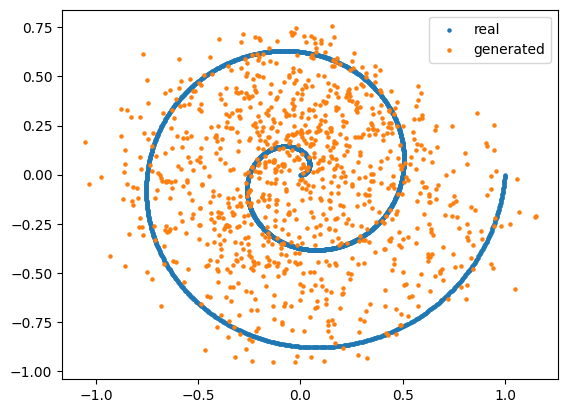

In [46]:
model = Model().to(device)
model = train(model, mode='eps', epochs=10000)

real = make_spiral(2000)
fake = sample(model, mode='eps')

print('MMD:', compute_mmd(real, fake).item())
print('Chamfer:', chamfer_distance(real, fake).item())

plt.scatter(real[:,0], real[:,1], s=5, label='real')
plt.scatter(fake[:,0], fake[:,1], s=5, label='generated')
plt.legend()
plt.show()

MMD: 0.03979836404323578
Chamfer: 0.17328613996505737


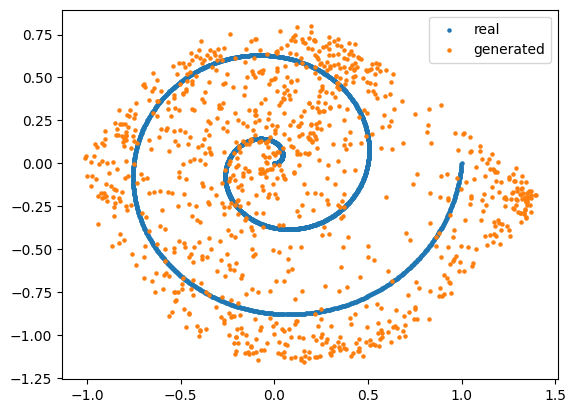

In [49]:
model = Model().to(device)
model = train(model, mode='x0', epochs=10000)

real = make_spiral(2000)
fake = sample(model, mode='x0')

print('MMD:', compute_mmd(real, fake).item())
print('Chamfer:', chamfer_distance(real, fake).item())

plt.scatter(real[:,0], real[:,1], s=5, label='real')
plt.scatter(fake[:,0], fake[:,1], s=5, label='generated')
plt.legend()
plt.show()

MMD: 0.021081842482089996
Chamfer: 0.1110987663269043


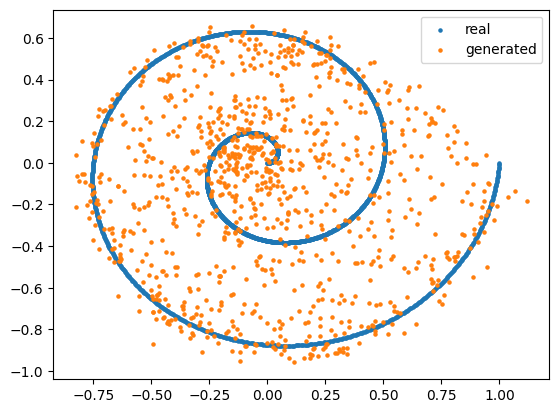

In [48]:
model = Model().to(device)
model = train(model, mode='v', epochs=10000)

real = make_spiral(2000)
fake = sample(model, mode='v')

print('MMD:', compute_mmd(real, fake).item())
print('Chamfer:', chamfer_distance(real, fake).item())

plt.scatter(real[:,0], real[:,1], s=5, label='real')
plt.scatter(fake[:,0], fake[:,1], s=5, label='generated')
plt.legend()
plt.show()

## Model Structure and Training Epoch Experiments

调整 MLP width, depth, training epochs 然后对比分析.

In [50]:
# 可调MLP：用于比较网络宽度、深度和训练轮次的影响
class MLPModel(nn.Module):
    def __init__(self, hidden_dim=256, depth=4):
        super().__init__()
        layers = []
        in_dim = 3  # 输入为(x, y, t)

        for _ in range(depth):
            layers.append(nn.Linear(in_dim, hidden_dim))
            layers.append(nn.SiLU())
            in_dim = hidden_dim

        layers.append(nn.Linear(hidden_dim, 2))
        self.net = nn.Sequential(*layers)

    def forward(self, x, t):
        # 与基础模型保持一致：时间步归一化后拼接到二维坐标后面
        if t.dim() == 1:
            t = t.unsqueeze(1)
        t = t.float() / (T - 1)
        inp = torch.cat([x, t], dim=1)
        return self.net(inp)


def evaluate_setting(hidden_dim=256, depth=4, epochs=10000, mode='v', seed=42):
    # 固定随机种子，减少不同配置之间的随机波动
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    model = MLPModel(hidden_dim=hidden_dim, depth=depth).to(device)
    model = train(model, mode=mode, epochs=epochs)

    real = make_spiral(2000)
    fake = sample(model, mode=mode)

    return {
        'hidden_dim': hidden_dim,
        'depth': depth,
        'epochs': epochs,
        'mode': mode,
        'mmd': compute_mmd(real, fake).item(),
        'chamfer': chamfer_distance(real, fake).item(),
        'fake': fake,
    }


In [51]:
# 根据前面实验结果选择一个模式做结构/轮次对比；可改为'eps'或'x0'
experiment_mode = 'v'

experiment_configs = [
    {'hidden_dim': 128, 'depth': 4, 'epochs': 10000},  # 更窄
    {'hidden_dim': 256, 'depth': 4, 'epochs': 10000},  # 基准宽度
    {'hidden_dim': 512, 'depth': 4, 'epochs': 10000},  # 更宽
    {'hidden_dim': 256, 'depth': 6, 'epochs': 10000},  # 更深
    {'hidden_dim': 256, 'depth': 4, 'epochs': 30000},  # 更多训练轮次
]

experiment_results = []
for cfg in experiment_configs:
    print(f"Running hidden={cfg['hidden_dim']}, depth={cfg['depth']}, epochs={cfg['epochs']}, mode={experiment_mode}")
    result = evaluate_setting(**cfg, mode=experiment_mode)
    experiment_results.append(result)
    print(f"  MMD={result['mmd']:.6f}, Chamfer={result['chamfer']:.6f}")

print('\nSummary:')
print(f"{'hidden':>8} {'depth':>6} {'epochs':>8} {'mode':>5} {'MMD':>12} {'Chamfer':>12}")
for r in experiment_results:
    print(f"{r['hidden_dim']:>8} {r['depth']:>6} {r['epochs']:>8} {r['mode']:>5} {r['mmd']:>12.6f} {r['chamfer']:>12.6f}")


Running hidden=128, depth=4, epochs=10000, mode=v
  MMD=0.033268, Chamfer=0.140384
Running hidden=256, depth=4, epochs=10000, mode=v
  MMD=0.013229, Chamfer=0.094650
Running hidden=512, depth=4, epochs=10000, mode=v
  MMD=0.006006, Chamfer=0.060511
Running hidden=256, depth=6, epochs=10000, mode=v
  MMD=0.006664, Chamfer=0.058992
Running hidden=256, depth=4, epochs=30000, mode=v
  MMD=0.004755, Chamfer=0.032316

Summary:
  hidden  depth   epochs  mode          MMD      Chamfer
     128      4    10000     v     0.033268     0.140384
     256      4    10000     v     0.013229     0.094650
     512      4    10000     v     0.006006     0.060511
     256      6    10000     v     0.006664     0.058992
     256      4    30000     v     0.004755     0.032316


Best setting: {'hidden_dim': 256, 'depth': 4, 'epochs': 30000, 'mode': 'v', 'mmd': 0.004754558205604553, 'chamfer': 0.03231602907180786}


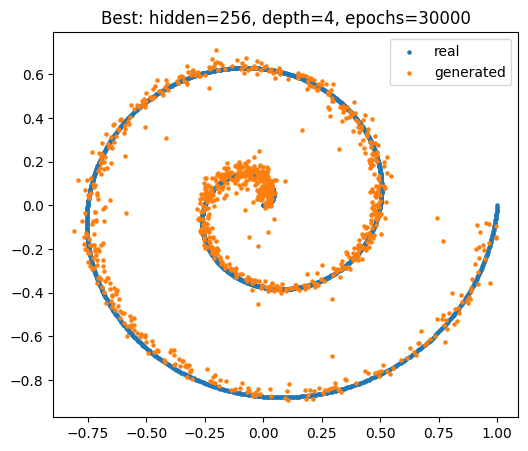

In [52]:
# 绘制Chamfer最小的配置，便于报告中展示
best = min(experiment_results, key=lambda r: r['chamfer'])
real = make_spiral(2000)
fake = best['fake']

print('Best setting:', {k: best[k] for k in ['hidden_dim', 'depth', 'epochs', 'mode', 'mmd', 'chamfer']})

plt.figure(figsize=(6, 5))
plt.scatter(real[:, 0], real[:, 1], s=5, label='real')
plt.scatter(fake[:, 0], fake[:, 1], s=5, label='generated')
plt.title(f"Best: hidden={best['hidden_dim']}, depth={best['depth']}, epochs={best['epochs']}")
plt.legend()
plt.show()
